# Gravitational Molecule: Parallel Adaptive Binary-Black-Hole Evolution for Six Eigenstates

This notebook uses the same initial system parameters as `gm.ipynb` and creates an independent counterfactual physical branch for each of the six tracked eigenstates, evolving adaptively from $R=38$ to $R=10$. The branches do not share their evolved $M_1$, $M_2$, or $M_c$, so mass exchange from the six states is never accumulated into one system.

Each branch uses $\epsilon_\Gamma=|\Delta t\,\Gamma_{\rm cloud}|$ as its step-size control variable, where $\Gamma_{\rm cloud}=2\operatorname{Im}E$. The six branches are scheduled concurrently by threads and share one underlying multiprocessing integration pool.

Each state uses an independent atomic JSON checkpoint containing the complete physical state, controller, cross-step eigenvector reference, accepted/rejected counts, and history. Checkpoints are validated and resumed independently on subsequent runs.


## 1. Imports and project paths

This notebook requires `tqdm`. If it is missing from the current kernel, install it in the project environment and rerun this cell.

In [1]:
from concurrent.futures import (
    ProcessPoolExecutor, ThreadPoolExecutor, as_completed,
)
from dataclasses import asdict
from hashlib import sha256
from pathlib import Path
import json
import math
import os
import sys

# Use single-threaded numerical kernels in each multiprocessing worker to avoid nested oversubscription
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(variable, "1")

import numpy as np
from tqdm.auto import tqdm

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, *working_directory.parents)
    if (candidate / "src" / "gmlib.py").is_file()
)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from gmlib import (
    PLANCK_TIMES_PER_YEAR,
    EigenvalueDegeneracyError,
    IntegrationSettings,
    IterationState,
    apply_mass_exchange,
    build_nonhermitian_hamiltonians,
    compute_cloud_observables,
    compute_iteration_tables,
    compute_orbital_observables,
    compute_signed_rates,
    diagonalize_and_track,
)

np.set_printoptions(precision=8, suppress=False)
PROJECT_ROOT

PosixPath('/global/u1/l/liuyh15/WorkSpace/GM')

## 2. Physical Parameters, Six-State Branches, and Adaptive Control

The physical parameters match `gm.ipynb`. `SELECTED_STATES=range(6)` creates an independent branch for each state. `TARGET_ABS_RATE_EXPONENT` and `MAX_ABS_RATE_EXPONENT` control $|\Delta t\,\Gamma_{\rm cloud}|$ for every branch; `DERIVATIVE_STENCIL_STEP` is independent of the adaptive evolution step.

The six threads only schedule branch state machines. All integration tasks share the `INTEGRATION` process pool to avoid oversubscription from six nested pools.


In [2]:
# Evolve the six eigenstates as independent counterfactual physical branches
M1_SOLAR = 40.0
MASS_RATIO = 0.99
ALPHA1 = 0.1
CLOUD_MASS_FRACTION = 0.01
SPIN_PRIMARY = 1.0
SPIN_SECONDARY = 1.0
R_START = 38.0
R_END = 10.0
SELECTED_STATES = tuple(range(6))
BRANCH_THREAD_WORKERS = len(SELECTED_STATES)

# gm.ipynb uses 200 grid points; use the same spacing as the initial candidate step here
REFERENCE_GRID_POINTS = 200
INITIAL_STEP = (R_START - R_END) / (REFERENCE_GRID_POINTS - 1)

# Primary adaptive error measure: the dimensionless cloud growth exponent |Delta t * Gamma_cloud|
TARGET_ABS_RATE_EXPONENT = 0.05
MAX_ABS_RATE_EXPONENT = 0.10
MAX_CLOUD_MASS_RATIO = 0.10
MIN_CLOUD_MASS_RATIO = 1.0e-5
TRACKING_ALGORITHM = "cross-step-hungarian-right-overlap-v1"
DEGENERACY_RELATIVE_TOLERANCE = 1.0e-10
DERIVATIVE_STENCIL_STEP = INITIAL_STEP
MIN_STEP = 128.0 * np.spacing(R_START)
MAX_STEP = INITIAL_STEP * 4.0
SAFETY = 0.90
MIN_FACTOR = 0.05
MAX_FACTOR = 2.00
MAX_REJECTIONS_PER_STEP = 16

# All six branches share one underlying process pool; threads only schedule branch state machines
INTEGRATION = IntegrationSettings(workers=-1, verbose=False)

CHECKPOINT_DIRECTORY = PROJECT_ROOT / "data" / "iteration_checkpoints"
# Paths may be overridden by internal zero-based state, for example {0: "data/state1.json"}
CHECKPOINT_PATH_OVERRIDES = {}
RESUME = True
RESET_CHECKPOINT = False

assert 0.0 < R_END < R_START
assert 0.0 < TARGET_ABS_RATE_EXPONENT <= MAX_ABS_RATE_EXPONENT < 1.0
assert 0.0 < MIN_CLOUD_MASS_RATIO < MAX_CLOUD_MASS_RATIO < 1.0
assert 0.0 < DEGENERACY_RELATIVE_TOLERANCE < 1.0
assert 0.0 < MIN_STEP <= INITIAL_STEP <= MAX_STEP
assert 0.0 < DERIVATIVE_STENCIL_STEP < R_END
assert SELECTED_STATES == tuple(range(6))
assert REFERENCE_GRID_POINTS >= 2


def make_initial_state(selected_state):
    return IterationState.from_ratios(
        primary_mass_solar=M1_SOLAR,
        mass_ratio=MASS_RATIO,
        alpha_primary=ALPHA1,
        cloud_mass_fraction=CLOUD_MASS_FRACTION,
        spin_primary=SPIN_PRIMARY,
        spin_secondary=SPIN_SECONDARY,
        separation=R_START,
        selected_state=selected_state,
    )


initial_states = {
    selected_state: make_initial_state(selected_state)
    for selected_state in SELECTED_STATES
}
{
    "initial states": {
        selected_state + 1: state.summary()
        for selected_state, state in initial_states.items()
    },
    "initial step": INITIAL_STEP,
    "target/max |Delta t Gamma_cloud|": (
        TARGET_ABS_RATE_EXPONENT,
        MAX_ABS_RATE_EXPONENT,
    ),
    "qc range": (MIN_CLOUD_MASS_RATIO, MAX_CLOUD_MASS_RATIO),
    "tracking": TRACKING_ALGORITHM,
    "degeneracy relative tolerance": DEGENERACY_RELATIVE_TOLERANCE,
    "branch threads/shared process workers": (
        BRANCH_THREAD_WORKERS,
        INTEGRATION.resolved_workers,
    ),
    "checkpoint directory": str(CHECKPOINT_DIRECTORY),
}


{'initial states': {1: {'M1_solar': 40.0,
   'M2_solar': 39.6,
   'Mc_solar': 0.4,
   'q': 0.99,
   'qc': 0.01,
   'alpha1': 0.09999999999999999,
   'alpha2': 0.099,
   'a1': 1.0,
   'a2': 1.0,
   'R': 38.0,
   'state': 1},
  2: {'M1_solar': 40.0,
   'M2_solar': 39.6,
   'Mc_solar': 0.4,
   'q': 0.99,
   'qc': 0.01,
   'alpha1': 0.09999999999999999,
   'alpha2': 0.099,
   'a1': 1.0,
   'a2': 1.0,
   'R': 38.0,
   'state': 2},
  3: {'M1_solar': 40.0,
   'M2_solar': 39.6,
   'Mc_solar': 0.4,
   'q': 0.99,
   'qc': 0.01,
   'alpha1': 0.09999999999999999,
   'alpha2': 0.099,
   'a1': 1.0,
   'a2': 1.0,
   'R': 38.0,
   'state': 3},
  4: {'M1_solar': 40.0,
   'M2_solar': 39.6,
   'Mc_solar': 0.4,
   'q': 0.99,
   'qc': 0.01,
   'alpha1': 0.09999999999999999,
   'alpha2': 0.099,
   'a1': 1.0,
   'a2': 1.0,
   'R': 38.0,
   'state': 4},
  5: {'M1_solar': 40.0,
   'M2_solar': 39.6,
   'Mc_solar': 0.4,
   'q': 0.99,
   'qc': 0.01,
   'alpha1': 0.09999999999999999,
   'alpha2': 0.099,
   'a1': 1

## 3. Independent checkpoints for six states

The schema-4 configuration fingerprint covers each branch's selected state, physical parameters, error controls, integration settings, and tracking settings. States 1–6 each have their own file, history, controller, and 6×6 complex reference eigenvectors.

JSON is first written to a temporary file and then replaced atomically. `RESET_CHECKPOINT=True` removes the six checkpoints for the current six-state configuration; `CHECKPOINT_PATH_OVERRIDES` can override each zero-based state path independently. Legacy single-state schemas are not resumed automatically.


In [ ]:
CHECKPOINT_SCHEMA = 4


def run_config_for_state(selected_state):
    return {
        "physics": {
            "M1_SOLAR": M1_SOLAR,
            "MASS_RATIO": MASS_RATIO,
            "ALPHA1": ALPHA1,
            "CLOUD_MASS_FRACTION": CLOUD_MASS_FRACTION,
            "SPIN_PRIMARY": SPIN_PRIMARY,
            "SPIN_SECONDARY": SPIN_SECONDARY,
            "R_START": R_START,
            "R_END": R_END,
            "SELECTED_STATE": int(selected_state),
        },
        "adaptive": {
            "REFERENCE_GRID_POINTS": REFERENCE_GRID_POINTS,
            "INITIAL_STEP": INITIAL_STEP,
            "TARGET_ABS_RATE_EXPONENT": TARGET_ABS_RATE_EXPONENT,
            "MAX_ABS_RATE_EXPONENT": MAX_ABS_RATE_EXPONENT,
            "MIN_CLOUD_MASS_RATIO": MIN_CLOUD_MASS_RATIO,
            "MAX_CLOUD_MASS_RATIO": MAX_CLOUD_MASS_RATIO,
            "DERIVATIVE_STENCIL_STEP": DERIVATIVE_STENCIL_STEP,
            "MIN_STEP": MIN_STEP,
            "MAX_STEP": MAX_STEP,
            "SAFETY": SAFETY,
            "MIN_FACTOR": MIN_FACTOR,
            "MAX_FACTOR": MAX_FACTOR,
            "MAX_REJECTIONS_PER_STEP": MAX_REJECTIONS_PER_STEP,
        },
        "integration": asdict(INTEGRATION),
        "tracking": {
            "algorithm": TRACKING_ALGORITHM,
            "degeneracy_relative_tolerance": DEGENERACY_RELATIVE_TOLERANCE,
        },
        "ensemble": {"selected_states": list(SELECTED_STATES)},
    }


RUN_CONFIGS = {
    selected_state: run_config_for_state(selected_state)
    for selected_state in SELECTED_STATES
}
CONFIG_HASHES = {
    selected_state: sha256(
        json.dumps(config, sort_keys=True, separators=(",", ":")).encode("utf-8")
    ).hexdigest()
    for selected_state, config in RUN_CONFIGS.items()
}


def _number_token(value):
    return format(float(value), ".8g").replace("-", "m").replace(".", "p")


def _checkpoint_stem(selected_state):
    return (
        f"iteration_M1{_number_token(M1_SOLAR)}"
        f"_q{_number_token(MASS_RATIO)}"
        f"_a{_number_token(ALPHA1)}"
        f"_qc{_number_token(CLOUD_MASS_FRACTION)}"
        f"_R{_number_token(R_START)}-{_number_token(R_END)}"
        f"_s{selected_state + 1}_{CONFIG_HASHES[selected_state][:12]}"
    )


AUTO_CHECKPOINT_PATHS = {
    selected_state: CHECKPOINT_DIRECTORY / f"{_checkpoint_stem(selected_state)}.json"
    for selected_state in SELECTED_STATES
}


def _state_to_dict(state):
    return {
        key: float(value) if isinstance(value, np.floating) else value
        for key, value in asdict(state).items()
    }


def _state_from_dict(payload):
    return IterationState(**payload)


def _complex_matrix_to_dict(matrix):
    if matrix is None:
        return None
    array = np.asarray(matrix, dtype=np.complex128)
    if array.shape != (6, 6) or not np.all(np.isfinite(array)):
        raise ValueError("tracking reference must be a finite (6, 6) matrix")
    return {"real": array.real.tolist(), "imag": array.imag.tolist()}


def _complex_matrix_from_dict(payload):
    if payload is None:
        return None
    array = np.asarray(payload["real"], dtype=np.float64) + 1j * np.asarray(
        payload["imag"], dtype=np.float64
    )
    if array.shape != (6, 6) or not np.all(np.isfinite(array)):
        raise RuntimeError("the checkpoint tracking reference is not a finite (6, 6) matrix")
    return array


def _checkpoint_payload_matches(path, selected_state):
    try:
        with path.open("r", encoding="utf-8") as stream:
            payload = json.load(stream)
    except (OSError, ValueError, TypeError, json.JSONDecodeError):
        return False
    return (
        payload.get("schema") == CHECKPOINT_SCHEMA
        and payload.get("config_hash") == CONFIG_HASHES[selected_state]
        and payload.get("config") == RUN_CONFIGS[selected_state]
    )


def _resolve_checkpoint_path(selected_state):
    override = CHECKPOINT_PATH_OVERRIDES.get(selected_state)
    if override is not None:
        explicit = Path(override).expanduser()
        return explicit if explicit.is_absolute() else PROJECT_ROOT / explicit

    automatic = AUTO_CHECKPOINT_PATHS[selected_state]
    candidates = [automatic]
    if CHECKPOINT_DIRECTORY.exists():
        candidates.extend(sorted(CHECKPOINT_DIRECTORY.glob("iteration_*.json")))
    for candidate in candidates:
        if candidate.exists() and _checkpoint_payload_matches(candidate, selected_state):
            return candidate
    return automatic


CHECKPOINT_PATHS = {
    selected_state: _resolve_checkpoint_path(selected_state)
    for selected_state in SELECTED_STATES
}


def save_checkpoint(
    *, selected_state, state, next_step, elapsed_planck, accepted, rejected,
    history, tracking_reference_vectors,
):
    path = CHECKPOINT_PATHS[selected_state]
    payload = {
        "schema": CHECKPOINT_SCHEMA,
        "config_hash": CONFIG_HASHES[selected_state],
        "config": RUN_CONFIGS[selected_state],
        "state": _state_to_dict(state),
        "tracking": {
            "reference_right_vectors": _complex_matrix_to_dict(
                tracking_reference_vectors
            ),
        },
        "controller": {
            "next_step": float(next_step),
            "elapsed_planck": float(elapsed_planck),
            "accepted": int(accepted),
            "rejected": int(rejected),
        },
        "history": history,
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8") as stream:
        json.dump(payload, stream, ensure_ascii=False, indent=2, allow_nan=False)
        stream.flush()
    temporary.replace(path)


def load_checkpoint(selected_state):
    path = CHECKPOINT_PATHS[selected_state]
    with path.open("r", encoding="utf-8") as stream:
        payload = json.load(stream)
    if not _checkpoint_payload_matches(path, selected_state):
        raise RuntimeError(
            f"state {selected_state + 1} checkpoint schema/config does not match the current notebook"
        )
    state = _state_from_dict(payload["state"])
    if state.selected_state != selected_state:
        raise RuntimeError("checkpoint selected_state does not match its branch file")
    controller = payload["controller"]
    tracking_reference_vectors = _complex_matrix_from_dict(
        payload.get("tracking", {}).get("reference_right_vectors")
    )
    if int(controller["accepted"]) > 0 and tracking_reference_vectors is None:
        raise RuntimeError("checkpoint has accepted steps but lacks a cross-step tracking reference")
    if not (R_END - 1e-12 <= state.separation <= R_START + 1e-12):
        raise RuntimeError("checkpoint separation lies outside the current evolution interval")
    return {
        "state": state,
        "next_step": float(controller["next_step"]),
        "elapsed_planck": float(controller["elapsed_planck"]),
        "accepted": int(controller["accepted"]),
        "rejected": int(controller["rejected"]),
        "history": list(payload["history"]),
        "tracking_reference_vectors": tracking_reference_vectors,
    }


if RESET_CHECKPOINT:
    for selected_state, path in CHECKPOINT_PATHS.items():
        if path.exists():
            path.unlink()
            print(f"explicitly removed state {selected_state + 1} checkpoint: {path}")


## 4. Single-Branch Physical Evolution, Cross-Step Tracking, and Growth-Exponent Control

For every branch, `compute_trial` reuses the full numerical chain from `gm.ipynb`: three-point operators, the non-Hermitian eigensystem, Hungarian-overlap tracking across accepted steps, biorthogonal cloud observables, GW orbital quantities, and signed rates. Mass exchange is applied to a branch only when $|\Delta t\,\Gamma_{\rm cloud}|$ does not exceed the hard limit.

A genuine complex-energy degeneracy immediately prints the branch and step parameters and raises an error. Each state records its minimum tracking overlap, central permutation, and minimum relative energy gap in its own history.


In [ ]:
def compute_trial(
    state, delta_r, *, reference_right_vectors=None, executor=None
):
    if not (0.0 < delta_r < state.separation):
        raise ValueError("delta_r must be positive and smaller than the current separation")

    tables = compute_iteration_tables(
        state,
        DERIVATIVE_STENCIL_STEP,
        INTEGRATION,
        executor=executor,
    )
    hamiltonian, widths = build_nonhermitian_hamiltonians(state, tables)
    eigensystem = diagonalize_and_track(
        hamiltonian,
        widths,
        reference_right_vectors=reference_right_vectors,
        degeneracy_relative_tolerance=DEGENERACY_RELATIVE_TOLERANCE,
    )
    cloud = compute_cloud_observables(state, tables, eigensystem)
    orbital = compute_orbital_observables(
        state,
        delta_r,
        tables,
        eigensystem,
        cloud,
        selected_state_only=True,
    )
    rates = compute_signed_rates(state, eigensystem)

    # rates.total = 2 Im(E), the cloud mass growth rate used by apply_mass_exchange
    exponent = float(rates.total * orbital.delta_time)
    exponent_abs = abs(exponent)
    if not np.isfinite(exponent):
        raise FloatingPointError("candidate step produced a non-finite Delta t * Gamma_cloud")

    selected = state.selected_state
    result = {
        "next_state": None,
        "delta_time": float(orbital.delta_time),
        "rate_exponent": exponent,
        "rate_exponent_abs": exponent_abs,
        "rate_total": float(rates.total),
        "gw_frequency_planck": float(
            np.sqrt(orbital.gw_frequency_squared[1, selected])
        ),
        "gr_power": float(orbital.gr_power[1, selected]),
        "tracking_reference_vectors": eigensystem.right_vectors[1].copy(),
        "tracking_minimum_overlap": (
            None
            if eigensystem.reference_overlaps is None
            else float(eigensystem.minimum_reference_overlap)
        ),
        "tracking_center_permutation": [
            int(value) for value in eigensystem.permutations[1]
        ],
        "minimum_relative_eigenvalue_gap": float(
            eigensystem.minimum_relative_eigenvalue_gap
        ),
    }

    # An oversized candidate step provides error information only; do not apply a potentially large mass exchange
    if exponent_abs > MAX_ABS_RATE_EXPONENT:
        return result

    exchange = apply_mass_exchange(
        state, delta_r, orbital.delta_time, rates
    )
    next_state = exchange.next_state
    total_before = (
        state.primary_mass_solar
        + state.secondary_mass_solar
        + state.cloud_mass_solar
    )
    total_after = (
        next_state.primary_mass_solar
        + next_state.secondary_mass_solar
        + next_state.cloud_mass_solar
    )
    if not np.isclose(total_before, total_after, rtol=0.0, atol=2e-12):
        raise FloatingPointError("single-step evolution failed the total-mass conservation check")
    if eigensystem.eigen_residual_max >= 1e-9:
        raise FloatingPointError("eigensystem residual exceeds 1e-9")
    if eigensystem.biorthogonality_max_error >= 1e-9:
        raise FloatingPointError("biorthogonality error exceeds 1e-9")

    result["next_state"] = next_state
    return result


def growth_step_factor(rate_exponent_abs, accepted):
    if not np.isfinite(rate_exponent_abs):
        return MIN_FACTOR
    if rate_exponent_abs <= np.finfo(float).tiny:
        raw = MAX_FACTOR
    else:
        # Delta t * Gamma is locally approximately proportional to delta_R
        raw = SAFETY * TARGET_ABS_RATE_EXPONENT / rate_exponent_abs
    upper = MAX_FACTOR if accepted else min(0.90, MAX_FACTOR)
    return float(np.clip(raw, MIN_FACTOR, upper))


def enforce_qc_limit(
    current_state,
    *,
    trial,
    trial_step,
    remaining,
    elapsed_planck,
    accepted,
    rejected,
    local_rejection,
    progress,
):
    candidate_state = None if trial is None else trial.get("next_state")
    offending_state = (
        current_state
        if current_state.cloud_mass_fraction >= MAX_CLOUD_MASS_RATIO
        else candidate_state
    )
    if (
        offending_state is None
        or offending_state.cloud_mass_fraction < MAX_CLOUD_MASS_RATIO
    ):
        return

    trial_parameters = None
    if trial is not None:
        trial_parameters = {
            "delta_time_planck": float(trial["delta_time"]),
            "delta_time_year": float(
                trial["delta_time"] / PLANCK_TIMES_PER_YEAR
            ),
            "rate_total_planck^-1": float(trial["rate_total"]),
            "delta_t_times_Gamma_cloud": float(trial["rate_exponent"]),
            "abs_delta_t_times_Gamma_cloud": float(
                trial["rate_exponent_abs"]
            ),
            "gw_frequency_planck": float(trial["gw_frequency_planck"]),
            "gr_power": float(trial["gr_power"]),
        }

    diagnostic = {
        "error": "cloud mass ratio qc must remain strictly below limit",
        "qc_limit_strict": float(MAX_CLOUD_MASS_RATIO),
        "offending_qc": float(offending_state.cloud_mass_fraction),
        "step": int(accepted + 1),
        "local_rejection": int(local_rejection),
        "accepted_before_step": int(accepted),
        "rejected_before_step": int(rejected),
        "elapsed_planck_before_step": float(elapsed_planck),
        "elapsed_year_before_step": float(
            elapsed_planck / PLANCK_TIMES_PER_YEAR
        ),
        "trial_delta_R": float(trial_step),
        "remaining_delta_R": float(remaining),
        "R_candidate": float(current_state.separation - trial_step),
        "current_state": current_state.summary(),
        "candidate_state": (
            None if candidate_state is None else candidate_state.summary()
        ),
        "trial_parameters": trial_parameters,
    }
    progress.write(
        "qc LIMIT ERROR -- offending step parameters:\n"
        + json.dumps(diagnostic, ensure_ascii=False, indent=2)
    )
    raise RuntimeError(
        f"step {accepted + 1}: qc={offending_state.cloud_mass_fraction:.16g} "
        f"must be strictly less than {MAX_CLOUD_MASS_RATIO:.16g}"
    )

## 5. Initialize or resume six branches

With the default `RESUME=True`, the notebook looks independently for six exactly matching schema-4 checkpoints. A missing branch starts from its own initial state and creates a new checkpoint. A rejected step or tracking reference in one branch does not affect any other branch.


In [5]:
runtimes = {}
resume_messages = {}
for selected_state in SELECTED_STATES:
    path = CHECKPOINT_PATHS[selected_state]
    if RESUME and path.exists():
        runtime = load_checkpoint(selected_state)
        message = "resumed from matching checkpoint"
    elif path.exists():
        raise FileExistsError(
            f"{path} already exists; enable RESUME, choose another path, or explicitly set RESET_CHECKPOINT"
        )
    else:
        runtime = {
            "state": initial_states[selected_state],
            "next_step": INITIAL_STEP,
            "elapsed_planck": 0.0,
            "accepted": 0,
            "rejected": 0,
            "history": [],
            "tracking_reference_vectors": None,
        }
        save_checkpoint(selected_state=selected_state, **runtime)
        message = "created new checkpoint"
    runtimes[selected_state] = runtime
    resume_messages[selected_state] = message

{
    selected_state + 1: {
        "status": resume_messages[selected_state],
        "state": runtime["state"].summary(),
        "next step": runtime["next_step"],
        "elapsed [year]": runtime["elapsed_planck"] / PLANCK_TIMES_PER_YEAR,
        "accepted/rejected": (runtime["accepted"], runtime["rejected"]),
        "history rows": len(runtime["history"]),
        "has tracking reference": runtime["tracking_reference_vectors"] is not None,
        "checkpoint": str(CHECKPOINT_PATHS[selected_state]),
    }
    for selected_state, runtime in runtimes.items()
}


{1: {'status': 'resumed from matching checkpoint',
  'state': {'M1_solar': 36.258616849948716,
   'M2_solar': 40.120193372237594,
   'Mc_solar': 3.6211897778136897,
   'q': 1.106500932958074,
   'qc': 0.09987115043024074,
   'alpha1': 0.09064654212487178,
   'alpha2': 0.10030048343059397,
   'a1': 1.0,
   'a2': 1.0,
   'R': 37.3946510173184,
   'state': 1},
  'next step': 0.012389103617074914,
  'elapsed [year]': 0.9686131966991677,
  'accepted/rejected': (53, 2),
  'history rows': 53,
  'has tracking reference': True,
  'checkpoint': '/global/u1/l/liuyh15/WorkSpace/GM/data/iteration_checkpoints/iteration_M140_q0p99_a0p1_qc0p01_R38-10_s1_aaacfb5d6339.json'},
 2: {'status': 'resumed from matching checkpoint',
  'state': {'M1_solar': 41.32932323624566,
   'M2_solar': 34.678997871225405,
   'Mc_solar': 3.991678892528928,
   'q': 0.8390894201919099,
   'qc': 0.09658224669472062,
   'alpha1': 0.10332330809061414,
   'alpha2': 0.08669749467806351,
   'a1': 1.0,
   'a2': 1.0,
   'R': 36.61617

## 6. Parallel Adaptive Six-State Iteration (`tqdm`)

Six independent state machines advance concurrently through a `ThreadPoolExecutor` while sharing one persistent `ProcessPoolExecutor`. Total progress is the sum of the actual $R_{\rm start}-R$ completed by all branches; progress is not forced to 100% when a branch terminates early at the lower `qc` limit.

The corresponding state checkpoint is saved atomically after every acceptance or rejection. A `qc>=0.1` condition, genuine energy degeneracy, or unrecoverable numerical error reports only the affected state and its complete step parameters.


In [6]:
def evolve_branch(selected_state, runtime, *, integration_pool, progress):
    state = runtime["state"]
    next_step = runtime["next_step"]
    elapsed_planck = runtime["elapsed_planck"]
    accepted = runtime["accepted"]
    rejected = runtime["rejected"]
    history = runtime["history"]
    tracking_reference_vectors = runtime["tracking_reference_vectors"]

    separation_reached = (
        state.separation <= R_END + 32.0 * np.finfo(float).eps
    )
    qc_termination_reached = (
        state.cloud_mass_fraction < MIN_CLOUD_MASS_RATIO
    )
    finished = separation_reached or qc_termination_reached
    termination_reason = (
        "qc_below_minimum" if qc_termination_reached
        else ("R_END_reached" if separation_reached else None)
    )

    while not finished:
        remaining = state.separation - R_END
        trial_step = min(next_step, remaining)
        if trial_step <= 0.0:
            break
        enforce_qc_limit(
            state,
            trial=None,
            trial_step=trial_step,
            remaining=remaining,
            elapsed_planck=elapsed_planck,
            accepted=accepted,
            rejected=rejected,
            local_rejection=0,
            progress=progress,
        )

        accepted_this_step = False
        for local_rejection in range(MAX_REJECTIONS_PER_STEP + 1):
            try:
                trial = compute_trial(
                    state,
                    trial_step,
                    reference_right_vectors=tracking_reference_vectors,
                    executor=integration_pool,
                )
                exponent_abs = trial["rate_exponent_abs"]
                failure = None
            except EigenvalueDegeneracyError as exc:
                diagnostic = {
                    "error": type(exc).__name__,
                    "detail": str(exc),
                    "selected_state": int(selected_state + 1),
                    "step": int(accepted + 1),
                    "local_rejection": int(local_rejection),
                    "trial_delta_R": float(trial_step),
                    "remaining_delta_R": float(remaining),
                    "elapsed_year_before_step": float(
                        elapsed_planck / PLANCK_TIMES_PER_YEAR
                    ),
                    "accepted_before_step": int(accepted),
                    "rejected_before_step": int(rejected),
                    "current_state": state.summary(),
                    "has_tracking_reference": (
                        tracking_reference_vectors is not None
                    ),
                }
                progress.write(
                    "EIGENVALUE DEGENERACY -- branch/step parameters:\n"
                    + json.dumps(diagnostic, ensure_ascii=False, indent=2)
                )
                raise
            except (FloatingPointError, ValueError, OverflowError) as exc:
                trial = None
                exponent_abs = math.inf
                failure = f"{type(exc).__name__}: {exc}"

            enforce_qc_limit(
                state,
                trial=trial,
                trial_step=trial_step,
                remaining=remaining,
                elapsed_planck=elapsed_planck,
                accepted=accepted,
                rejected=rejected,
                local_rejection=local_rejection,
                progress=progress,
            )

            if trial is not None and trial["next_state"] is not None:
                previous_state = state
                state = trial["next_state"]
                if abs(state.separation - R_END) <= 1e-12:
                    state = IterationState(
                        **{
                            **asdict(state),
                            "separation": float(R_END),
                        }
                    )

                elapsed_planck += trial["delta_time"]
                accepted += 1
                tracking_reference_vectors = trial[
                    "tracking_reference_vectors"
                ]
                factor = growth_step_factor(exponent_abs, accepted=True)
                next_step = float(
                    np.clip(trial_step * factor, MIN_STEP, MAX_STEP)
                )

                row = {
                    "accepted": accepted,
                    "R_start": float(previous_state.separation),
                    "R_end": float(state.separation),
                    "delta_R": float(trial_step),
                    "delta_time_year": float(
                        trial["delta_time"] / PLANCK_TIMES_PER_YEAR
                    ),
                    "elapsed_year": float(
                        elapsed_planck / PLANCK_TIMES_PER_YEAR
                    ),
                    "rate_exponent": float(trial["rate_exponent"]),
                    "rate_exponent_abs": float(exponent_abs),
                    "M1_solar": float(state.primary_mass_solar),
                    "M2_solar": float(state.secondary_mass_solar),
                    "Mc_solar": float(state.cloud_mass_solar),
                    "q": float(state.mass_ratio),
                    "alpha1": float(state.alpha_primary),
                    "alpha2": float(state.alpha_secondary),
                    "gw_frequency_planck": float(
                        trial["gw_frequency_planck"]
                    ),
                    "gr_power": float(trial["gr_power"]),
                    "tracking_minimum_overlap": trial[
                        "tracking_minimum_overlap"
                    ],
                    "tracking_center_permutation": trial[
                        "tracking_center_permutation"
                    ],
                    "minimum_relative_eigenvalue_gap": float(
                        trial["minimum_relative_eigenvalue_gap"]
                    ),
                    "next_step": next_step,
                }
                history.append(row)
                save_checkpoint(
                    selected_state=selected_state,
                    state=state,
                    next_step=next_step,
                    elapsed_planck=elapsed_planck,
                    accepted=accepted,
                    rejected=rejected,
                    history=history,
                    tracking_reference_vectors=tracking_reference_vectors,
                )
                progress.update(previous_state.separation - state.separation)
                accepted_this_step = True
                break

            rejected += 1
            factor = growth_step_factor(exponent_abs, accepted=False)
            proposed = trial_step * factor
            endpoint_limited = remaining < MIN_STEP
            if proposed < MIN_STEP and not endpoint_limited:
                detail = failure or f"|Delta t Gamma|={exponent_abs:.6g}"
                raise RuntimeError(
                    f"state {selected_state + 1}: adaptive step size must be smaller than "
                    f"MIN_STEP={MIN_STEP:.6g}; {detail}"
                )
            trial_step = min(
                max(proposed, min(MIN_STEP, remaining)), remaining
            )
            next_step = trial_step
            save_checkpoint(
                selected_state=selected_state,
                state=state,
                next_step=next_step,
                elapsed_planck=elapsed_planck,
                accepted=accepted,
                rejected=rejected,
                history=history,
                tracking_reference_vectors=tracking_reference_vectors,
            )

        if not accepted_this_step:
            raise RuntimeError(
                f"state {selected_state + 1}: consecutive rejections at the same position exceeded "
                f"{MAX_REJECTIONS_PER_STEP} times"
            )
        separation_reached = (
            state.separation <= R_END + 32.0 * np.finfo(float).eps
        )
        qc_termination_reached = (
            state.cloud_mass_fraction < MIN_CLOUD_MASS_RATIO
        )
        if qc_termination_reached:
            termination_reason = "qc_below_minimum"
            progress.write(
                f"state {selected_state + 1} reached the termination condition: "
                f"qc={state.cloud_mass_fraction:.16g} "
                f"< {MIN_CLOUD_MASS_RATIO:.16g}; checkpoint saved."
            )
        elif separation_reached:
            termination_reason = "R_END_reached"
        finished = separation_reached or qc_termination_reached

    return {
        "state": state,
        "next_step": next_step,
        "elapsed_planck": elapsed_planck,
        "accepted": accepted,
        "rejected": rejected,
        "history": history,
        "tracking_reference_vectors": tracking_reference_vectors,
        "termination_reason": termination_reason,
        "checkpoint": CHECKPOINT_PATHS[selected_state],
    }


progress_total = sum(R_START - R_END for _ in SELECTED_STATES)
progress_initial = sum(
    float(np.clip(R_START - runtime["state"].separation, 0.0, R_START - R_END))
    for runtime in runtimes.values()
)
branch_results = {}
with ProcessPoolExecutor(
    max_workers=INTEGRATION.resolved_workers
) as integration_pool:
    # Start workers from the main thread before creating branch threads to avoid delayed forks inside threads.
    list(integration_pool.map(abs, range(INTEGRATION.resolved_workers)))
    with tqdm(
        total=progress_total,
        initial=progress_initial,
        desc="six-state adaptive BBH iteration",
        unit="Delta R",
        dynamic_ncols=True,
    ) as progress:
        with ThreadPoolExecutor(
            max_workers=BRANCH_THREAD_WORKERS
        ) as branch_pool:
            futures = {
                branch_pool.submit(
                    evolve_branch,
                    selected_state,
                    runtime,
                    integration_pool=integration_pool,
                    progress=progress,
                ): selected_state
                for selected_state, runtime in runtimes.items()
            }
            for future in as_completed(futures):
                selected_state = futures[future]
                branch_results[selected_state] = future.result()
                result = branch_results[selected_state]
                progress.write(
                    f"state {selected_state + 1} terminated: "
                    f"{result['termination_reason']}, "
                    f"R={result['state'].separation:.8g}, "
                    f"checkpoint={result['checkpoint']}"
                )

print("All six eigenstate branches have finished.")


six-state adaptive BBH iteration:   2%|#9                                                                     …

state 4 terminated: qc_below_minimum, R=37.999967, checkpoint=/global/u1/l/liuyh15/WorkSpace/GM/data/iteration_checkpoints/iteration_M140_q0p99_a0p1_qc0p01_R38-10_s4_8ef022c603b7.json
state 3 terminated: qc_below_minimum, R=37.999968, checkpoint=/global/u1/l/liuyh15/WorkSpace/GM/data/iteration_checkpoints/iteration_M140_q0p99_a0p1_qc0p01_R38-10_s3_5b548d904fa3.json
state 5 terminated: qc_below_minimum, R=37.571282, checkpoint=/global/u1/l/liuyh15/WorkSpace/GM/data/iteration_checkpoints/iteration_M140_q0p99_a0p1_qc0p01_R38-10_s5_7ee87d256833.json
state 6 terminated: qc_below_minimum, R=37.538149, checkpoint=/global/u1/l/liuyh15/WorkSpace/GM/data/iteration_checkpoints/iteration_M140_q0p99_a0p1_qc0p01_R38-10_s6_e704555b2cab.json
qc LIMIT ERROR -- offending step parameters:
{
  "error": "cloud mass ratio qc must remain strictly below limit",
  "qc_limit_strict": 0.1,
  "offending_qc": 0.10490237786673721,
  "step": 54,
  "local_rejection": 0,
  "accepted_before_step": 53,
  "rejected_befor

RuntimeError: step 54: qc=0.1049023778667372 must be strictly less than 0.1

## 7. Results and conservation checks

In [7]:
summaries = {}
for selected_state in SELECTED_STATES:
    runtime = (
        branch_results[selected_state]
        if selected_state in branch_results
        else load_checkpoint(selected_state)
    )
    state = runtime["state"]
    final_total = (
        state.primary_mass_solar
        + state.secondary_mass_solar
        + state.cloud_mass_solar
    )
    initial_state = initial_states[selected_state]
    initial_total = (
        initial_state.primary_mass_solar
        + initial_state.secondary_mass_solar
        + initial_state.cloud_mass_solar
    )
    mass_conservation_error = abs(final_total - initial_total)
    assert mass_conservation_error < 2e-10
    if state.separation <= R_END + 1e-12:
        assert state.separation == R_END
    termination_reason = runtime.get("termination_reason", "checkpoint_snapshot")
    summaries[selected_state + 1] = {
        "termination reason": termination_reason,
        "reached R_END": bool(state.separation == R_END),
        "final state": state.summary(),
        "elapsed [year]": runtime["elapsed_planck"] / PLANCK_TIMES_PER_YEAR,
        "accepted steps": runtime["accepted"],
        "rejected trials": runtime["rejected"],
        "mass conservation error [solar]": mass_conservation_error,
        "last tracking overlap": (
            runtime["history"][-1].get("tracking_minimum_overlap")
            if runtime["history"] else None
        ),
        "last relative eigenvalue gap": (
            runtime["history"][-1].get("minimum_relative_eigenvalue_gap")
            if runtime["history"] else None
        ),
        "checkpoint": str(CHECKPOINT_PATHS[selected_state]),
    }

summaries


{1: {'termination reason': 'checkpoint_snapshot',
  'reached R_END': False,
  'final state': {'M1_solar': 36.258616849948716,
   'M2_solar': 40.120193372237594,
   'Mc_solar': 3.6211897778136897,
   'q': 1.106500932958074,
   'qc': 0.09987115043024074,
   'alpha1': 0.09064654212487178,
   'alpha2': 0.10030048343059397,
   'a1': 1.0,
   'a2': 1.0,
   'R': 37.3946510173184,
   'state': 1},
  'elapsed [year]': 0.9686131966991677,
  'accepted steps': 53,
  'rejected trials': 2,
  'mass conservation error [solar]': 1.4210854715202004e-14,
  'last tracking overlap': 0.9999999945158801,
  'last relative eigenvalue gap': 0.03273388862530565,
  'checkpoint': '/global/u1/l/liuyh15/WorkSpace/GM/data/iteration_checkpoints/iteration_M140_q0p99_a0p1_qc0p01_R38-10_s1_aaacfb5d6339.json'},
 2: {'termination reason': 'checkpoint_snapshot',
  'reached R_END': False,
  'final state': {'M1_solar': 41.32932323624566,
   'M2_solar': 34.678997871225405,
   'Mc_solar': 3.991678892528928,
   'q': 0.839089420191

In [8]:
# The five most recent accepted steps for each eigenstate; complete histories are stored in their checkpoints
{
    selected_state + 1: (
        branch_results[selected_state]["history"][-5:]
        if selected_state in branch_results
        else load_checkpoint(selected_state)["history"][-5:]
    )
    for selected_state in SELECTED_STATES
}


{1: [{'accepted': 49,
   'R_start': 37.45509292361557,
   'R_end': 37.443178893478844,
   'delta_R': 0.011914030136722816,
   'delta_time_year': 0.02334761592352263,
   'elapsed_year': 0.8688350289363734,
   'rate_exponent': 0.044701701515850026,
   'rate_exponent_abs': 0.044701701515850026,
   'M1_solar': 36.85389315030661,
   'M2_solar': 40.11703294229065,
   'Mc_solar': 3.0290739074027413,
   'q': 1.0885426073895503,
   'alpha1': 0.09213473287576653,
   'alpha2': 0.10029258235572662,
   'gw_frequency_planck': 4.7737403775366565e-46,
   'gr_power': 1.1787703685614398e-17,
   'tracking_minimum_overlap': 0.9999999942868626,
   'tracking_center_permutation': [3, 0, 4, 1, 5, 2],
   'minimum_relative_eigenvalue_gap': 0.031900897364438484,
   'next_step': 0.011993533533895326},
  {'accepted': 50,
   'R_start': 37.443178893478844,
   'R_end': 37.43118535994495,
   'delta_R': 0.011993533533895326,
   'delta_time_year': 0.02393401694030107,
   'elapsed_year': 0.8927690458766745,
   'rate_expo

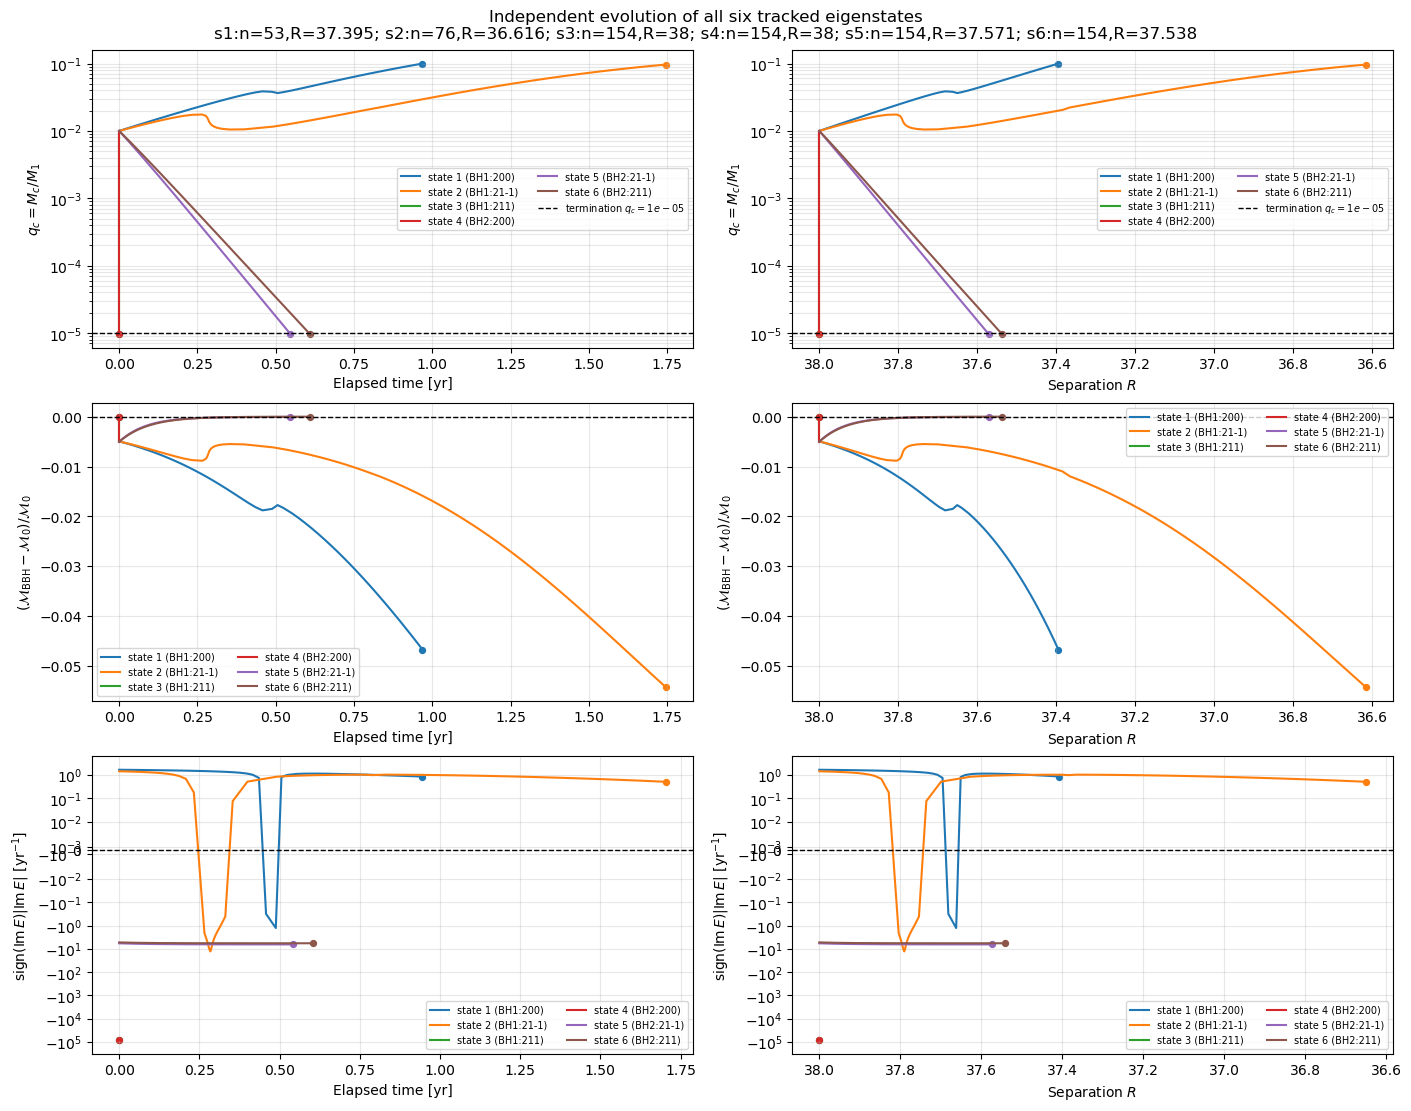

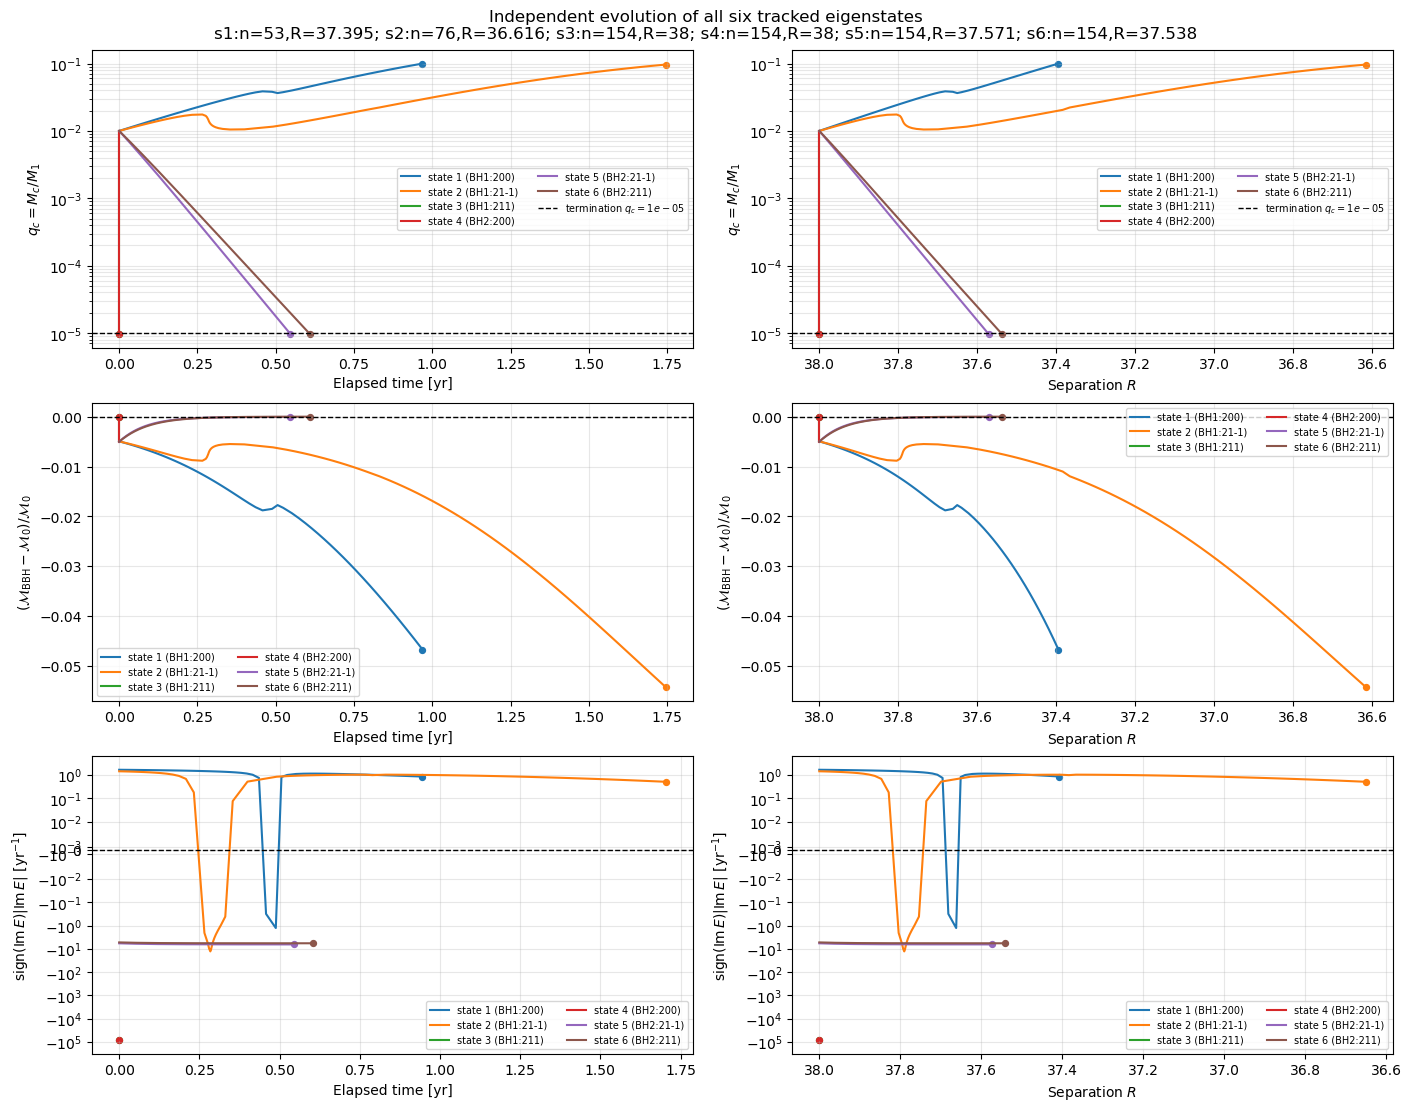

In [9]:
# Reload the final complete states from the six on-disk checkpoints
import matplotlib.pyplot as plt

STATE_LABELS = (
    "state 1 (BH1:200)",
    "state 2 (BH1:21-1)",
    "state 3 (BH1:211)",
    "state 4 (BH2:200)",
    "state 5 (BH2:21-1)",
    "state 6 (BH2:211)",
)
colors = plt.get_cmap("tab10")(np.arange(6))
figure, axes = plt.subplots(3, 2, figsize=(14, 11), constrained_layout=True)
qc_time_axis, qc_r_axis = axes[0]
chirp_time_axis, chirp_r_axis = axes[1]
energy_time_axis, energy_r_axis = axes[2]
all_nonzero_imaginary_energy = []
plot_status = []

for selected_state in SELECTED_STATES:
    checkpoint_path = CHECKPOINT_PATHS[selected_state]
    checkpoint_payload = json.loads(checkpoint_path.read_text(encoding="utf-8"))
    checkpoint_history = checkpoint_payload.get("history", [])
    physics = checkpoint_payload["config"]["physics"]
    label = STATE_LABELS[selected_state]
    color = colors[selected_state]

    initial_m1 = float(physics["M1_SOLAR"])
    initial_m2 = initial_m1 * float(physics["MASS_RATIO"])
    initial_mc = initial_m1 * float(physics["CLOUD_MASS_FRACTION"])
    time_year = np.asarray(
        [0.0] + [float(row["elapsed_year"]) for row in checkpoint_history]
    )
    separation = np.asarray(
        [float(physics["R_START"])]
        + [float(row["R_end"]) for row in checkpoint_history]
    )
    m1_solar = np.asarray(
        [initial_m1] + [float(row["M1_solar"]) for row in checkpoint_history]
    )
    m2_solar = np.asarray(
        [initial_m2] + [float(row["M2_solar"]) for row in checkpoint_history]
    )
    mc_solar = np.asarray(
        [initial_mc] + [float(row["Mc_solar"]) for row in checkpoint_history]
    )

    qc_values = mc_solar / m1_solar
    qc_for_log_plot = np.where(qc_values > 0.0, qc_values, np.nan)
    cloud_on_bh1 = selected_state < 3
    reference_m1 = initial_m1 + initial_mc if cloud_on_bh1 else initial_m1
    reference_m2 = initial_m2 if cloud_on_bh1 else initial_m2 + initial_mc
    reference_chirp_mass = (
        (reference_m1 * reference_m2) ** (3.0 / 5.0)
        / (reference_m1 + reference_m2) ** (1.0 / 5.0)
    )
    chirp_mass = (m1_solar * m2_solar) ** (3.0 / 5.0) / (
        m1_solar + m2_solar
    ) ** (1.0 / 5.0)
    relative_chirp_deviation = (
        chirp_mass - reference_chirp_mass
    ) / reference_chirp_mass

    qc_time_axis.plot(time_year, qc_for_log_plot, color=color, label=label)
    qc_r_axis.plot(separation, qc_for_log_plot, color=color, label=label)
    chirp_time_axis.plot(
        time_year, relative_chirp_deviation, color=color, label=label
    )
    chirp_r_axis.plot(
        separation, relative_chirp_deviation, color=color, label=label
    )
    qc_time_axis.scatter(time_year[-1], qc_for_log_plot[-1], color=color, s=18)
    qc_r_axis.scatter(separation[-1], qc_for_log_plot[-1], color=color, s=18)
    chirp_time_axis.scatter(
        time_year[-1], relative_chirp_deviation[-1], color=color, s=18
    )
    chirp_r_axis.scatter(
        separation[-1], relative_chirp_deviation[-1], color=color, s=18
    )

    if checkpoint_history:
        energy_time_year = np.asarray([
            float(row["elapsed_year"]) - float(row["delta_time_year"])
            for row in checkpoint_history
        ])
        energy_separation = np.asarray([
            float(row["R_start"]) for row in checkpoint_history
        ])
        energy_delta_time_year = np.asarray([
            float(row["delta_time_year"]) for row in checkpoint_history
        ])
        if np.any(energy_delta_time_year <= 0.0):
            raise ValueError(
                f"state {selected_state + 1} history has non-positive delta time"
            )
        imaginary_energy = np.asarray([
            float(row["rate_exponent"]) for row in checkpoint_history
        ]) / (2.0 * energy_delta_time_year)
        signed_imaginary_energy = np.sign(imaginary_energy) * np.abs(
            imaginary_energy
        )
        nonzero = np.abs(imaginary_energy[np.nonzero(imaginary_energy)])
        if nonzero.size:
            all_nonzero_imaginary_energy.append(nonzero)
        energy_time_axis.plot(
            energy_time_year, signed_imaginary_energy, color=color, label=label
        )
        energy_r_axis.plot(
            energy_separation, signed_imaginary_energy, color=color, label=label
        )
        energy_time_axis.scatter(
            energy_time_year[-1], signed_imaginary_energy[-1], color=color, s=18
        )
        energy_r_axis.scatter(
            energy_separation[-1], signed_imaginary_energy[-1], color=color, s=18
        )

    plot_status.append(
        f"s{selected_state + 1}:n={len(checkpoint_history)},"
        f"R={checkpoint_payload['state']['separation']:.5g}"
    )

for axis in (qc_time_axis, qc_r_axis):
    axis.set_yscale("log")
    axis.axhline(
        MIN_CLOUD_MASS_RATIO,
        color="black",
        linestyle="--",
        linewidth=1.0,
        label=rf"termination $q_c={MIN_CLOUD_MASS_RATIO:g}$",
    )
    axis.set_ylabel(r"$q_c=M_c/M_1$")

for axis in (chirp_time_axis, chirp_r_axis):
    axis.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    axis.set_ylabel(
        r"$(\mathcal{M}_{\rm BBH}-\mathcal{M}_0)/\mathcal{M}_0$"
    )

if all_nonzero_imaginary_energy:
    energy_linthresh = 0.1 * min(
        float(np.min(values)) for values in all_nonzero_imaginary_energy
    )
else:
    energy_linthresh = 1.0e-30
for axis in (energy_time_axis, energy_r_axis):
    axis.set_yscale("symlog", linthresh=energy_linthresh)
    axis.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    axis.set_ylabel(
        r"$\operatorname{sign}(\operatorname{Im}E)|\operatorname{Im}E|$"
        r" [yr$^{-1}$]"
    )

for axis in (qc_time_axis, chirp_time_axis, energy_time_axis):
    axis.set_xlabel("Elapsed time [yr]")
for axis in (qc_r_axis, chirp_r_axis, energy_r_axis):
    axis.set_xlabel(r"Separation $R$")
    axis.invert_xaxis()
for axis in axes.flat:
    axis.grid(True, which="both", alpha=0.3)
    axis.legend(fontsize=7, ncol=2)

figure.suptitle(
    "Independent evolution of all six tracked eigenstates\n"
    + "; ".join(plot_status)
)
plt.show()
figure
